In [42]:
import pandas as pd
chemin = "./data/raw/comptages.csv"
df = pd.read_csv(chemin, sep=";")
df.head(5)

,iu_ac,libelle,t_1h,q,k,etat_trafic,iu_nd_amont,libelle_nd_amont,iu_nd_aval,libelle_nd_aval,etat_barre
0,1960,Av_de_l'Opera,2026-08-31T23:00:00+00:00,156.0,1.74667,Fluide,2139,Pl_de_l'Opera,211,Av_de_l'Opera-Antin-Augustin,Ouvert
1,57,St_Jacques,2026-08-31T23:00:00+00:00,206.0,3.22778,Fluide,52,St_Jacques-Galande,53,Bd_St_Germain-St_Jacques,Ouvert
2,298,Av_de_l'Opera,2026-08-31T23:00:00+00:00,257.0,1.73667,Fluide,178,Av_de_l'Opera-Echelle,87,Pl_Andre_Malraux,Ouvert
3,300,Av_de_l'Opera,2026-08-31T23:00:00+00:00,158.0,2.21722,Fluide,177,Av_de_l'Opera-Pyramides,178,Av_de_l'Opera-Echelle,Ouvert
4,367,Av_de_l'Opera,2026-08-31T23:00:00+00:00,156.0,1.44167,Fluide,211,Av_de_l'Opera-Antin-Augustin,179,Av_de_l'Opera-Petits_Champs,Ouvert


**1 - Date en datetime et en heure de Paris, identifiants en texte, états en category**

In [43]:
# Dates en datetime, converties en heure de Paris
df["t_1h"] = pd.to_datetime(df["t_1h"]).dt.tz_convert("Europe/Paris")

# Identifiants en texte
df[["iu_ac", "iu_nd_amont", "iu_nd_aval"]] = df[["iu_ac", "iu_nd_amont", "iu_nd_aval"]].astype("string")

# États en category
df[["etat_trafic", "etat_barre"]] = df[["etat_trafic", "etat_barre"]].astype("category")

**2 - Doublons - Testez sur la bonne clé, écrivez le résultat**

In [44]:
doublons = df.duplicated(subset=["iu_ac", "t_1h"]).sum()
print(f"{doublons} doublons sur la clé (iu_ac, t_1h)")

0 doublons sur la clé (iu_ac, t_1h)


In [45]:
# Nombre de capteurs et d'heures distincts
print(f"{df['iu_ac'].nunique()} capteurs distincts")
print(f"{df['t_1h'].nunique()} heures distinctes")

# Doublons si on teste chaque colonne seule (pour comparaison)
print(f"{df.duplicated(subset=['iu_ac']).sum()} doublons sur iu_ac seul")
print(f"{df.duplicated(subset=['t_1h']).sum()} doublons sur t_1h seul")

33 capteurs distincts
4364 heures distinctes
143979 doublons sur iu_ac seul
139648 doublons sur t_1h seul


33 × 4364 tombe pile sur 144 012, sans reste  ça veut dire que : chaque capteur a une ligne pour chaque heure, aucune combinaison (pas de trou dans la grille capteur × heure).

In [46]:
pivot = df.pivot_table(index="t_1h", columns="iu_ac", values="q")

capteurs_q_identiques = pivot.T[pivot.T.duplicated(keep=False)]
print(f"{capteurs_q_identiques.shape[0]} capteurs ont exactement la même série de débit qu'un autre")
print(capteurs_q_identiques.index.tolist())

26 capteurs ont exactement la même série de débit qu'un autre
['1960', '299', '300', '301', '302', '303', '367', '5087', '5088', '5089', '5090', '5092', '5093', '5095', '5096', '5097', '5104', '5105', '5107', '57', '58', '595', '597', '598', '599', '600']


**3 - Colonnes supprimées : le test qui justifie chaque supression**

In [47]:
#1 Colonnes qu'on garde parce qu'elles apparaissent réellement dans l'analyse
colonnes_utilisees = ["libelle", "t_1h", "q", "k", "etat_trafic", "etat_barre", "iu_ac"]
df = df.drop(columns=df.columns.difference(colonnes_utilisees))

In [48]:
#2 Colonne constante : si elle ne prend qu'une seule valeur sur tout le fichier,
for col in df.columns:
    if df[col].nunique(dropna=False) == 1:
        print(f"{col} : constante (toujours '{df[col].iloc[0]}')  aucune info à supprimer")


In [49]:
#3 Colonne quasi vide : si toutes les valeurs sont manquantes,
seuil = 0.95
for col in df.columns:
    taux_nan = df[col].isna().mean()
    if taux_nan > seuil:
        print(f"{col} : {taux_nan:.1%} de valeurs manquantes à supprimer")

**4 - Valeur manquantes : que veulent dire l'état Barré et Invalide sur vos axes ? Que est la longueur de vos trous ? Choissisez votre méthode à partir de ces chiffres.**

In [50]:
df["etat_barre"].value_counts(dropna=False)

etat_barre
Ouvert      131796
Invalide     12024
Barré          192
Name: count, dtype: int64

In [51]:
df.groupby("etat_barre")["q"].agg(["count", "mean", "min", "max"])

,count,mean,min,max
etat_barre,,,,
Barré,162,110.654321,0.0,681.00
Invalide,0,NaN,NaN,NaN
Ouvert,118302,287.529467,0.0,5473.95


Invalide : 0 ligne sur 12 024 avec un débit mesuré.il n'y a aucune mesure du tout. "Invalide" , ça veut surement dire "le capteur n'a renvoyé aucune valeur exploitable" : c'est a priori un problème technique de l'équipement.

162 lignes sur 192 ont quand même un débit, avec une moyenne de 111 véh/h et un maximum de 681 véhicule/h. Là, il y a bien du passage détecté — mais le volume est trop élevé pour être uniquement des piétons, vélos ou engins de chantier : 681 véh/h, c'est même au-dessus du maximum relevé sur "Ouvert" (474 véh/h). Ça va plutôt dans le sens d'un autre problème, nous allons vérifier si c'est un cas isolé et en tirer une conclusion

In [52]:
df[df["etat_barre"] == "Barré"]["q"].describe()

count    162.000000
mean     110.654321
std      148.250364
min        0.000000
25%        2.000000
50%       32.000000
75%      168.000000
max      681.000000
Name: q, dtype: float64

25 % des heures « Barré » ontplus de  2 véhicules par heure  ça, ça colle  avec notre hypothèse (quelques piétons/vélos, route vraiment fermée).
Mais la médiane est déjà à 32 véh/h, et un quart des heures dépasse 168 véhicules par heures, c'est du vrai trafic routier, cela peut être expliqué par des routes qui sont partiellement fermé malgré des travaux.

In [53]:
trou = df.sort_values(["iu_ac", "t_1h"])["q"].isna()
nouveau_groupe = (trou != trou.shift()) | (df["iu_ac"] != df["iu_ac"].shift())
longueurs = trou[trou].groupby(nouveau_groupe.cumsum()[trou]).size()
longueurs.describe()

count    25542.000000
mean         1.000235
std          0.015325
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          2.000000
Name: q, dtype: float64

In [55]:
import matplotlib.pyplot as plt

# Taux de valeurs manquantes de q, mois par mois
taux_manquant_mois = df.set_index("t_1h")["q"].isna().resample("ME").mean()
taux_manquant_mois

t_1h
2026-03-31 00:00:00+02:00    0.101967
2026-04-30 00:00:00+02:00    0.158259
2026-05-31 00:00:00+02:00    0.114695
2026-06-30 00:00:00+02:00    0.143939
2026-07-31 00:00:00+02:00    0.237781
2026-08-31 00:00:00+02:00    0.302460
2026-09-30 00:00:00+02:00    0.272727
Freq: ME, Name: q, dtype: float64

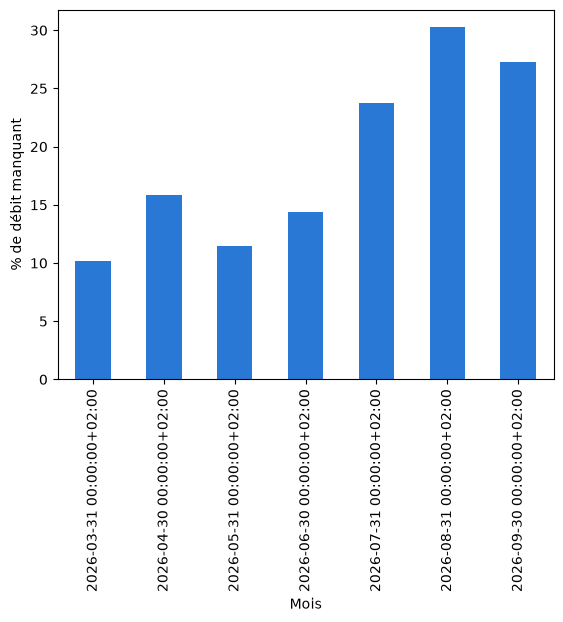

In [56]:
(taux_manquant_mois * 100).plot(kind="bar", color="#2a78d6")
plt.ylabel("% de débit manquant")
plt.xlabel("Mois")
plt.show()

In [57]:
manquants_mois = df.set_index("t_1h")["q"].isna().resample("ME").sum()
manquants_mois

t_1h
2026-03-31 00:00:00+02:00    2416
2026-04-30 00:00:00+02:00    3614
2026-05-31 00:00:00+02:00    2816
2026-06-30 00:00:00+02:00    3420
2026-07-31 00:00:00+02:00    5838
2026-08-31 00:00:00+02:00    7426
2026-09-30 00:00:00+02:00      18
Freq: ME, Name: q, dtype: int64

In [58]:
pd.DataFrame({
    "lignes_totales": df.set_index("t_1h")["q"].resample("ME").size(),
    "q_manquant": df.set_index("t_1h")["q"].isna().resample("ME").sum(),
})

,lignes_totales,q_manquant
t_1h,,
2026-03-31 00:00:00+02:00,23694,2416
2026-04-30 00:00:00+02:00,22836,3614
2026-05-31 00:00:00+02:00,24552,2816
2026-06-30 00:00:00+02:00,23760,3420
2026-07-31 00:00:00+02:00,24552,5838
2026-08-31 00:00:00+02:00,24552,7426
2026-09-30 00:00:00+02:00,66,18


Mars est à 10 % de manquant, et ça grimpe progressivement jusqu'à 30 % en août. Ce n'est pas un hasard réparti au fil des 6 mois  le taux de données manquantes se dégrade au fil du temps. Ca peut s'expliquer par l'usure des capteurs, ou des travaux qui s'intensifie durant les mois d'été.


In [61]:
from pathlib import Path

dossier_sortie = Path("data/processed")
dossier_sortie.mkdir(parents=True, exist_ok=True)
df.to_csv(dossier_sortie / "comptages_propre.csv", index=False)
print(f"{len(df)} lignes enregistrées dans {dossier_sortie / 'comptages_propre.csv'}")

144012 lignes enregistrées dans data/processed/comptages_propre.csv
